<a href="https://colab.research.google.com/github/AhmadBinAbdulJabbar/campusx/blob/main/13_end_to_end_ML_project_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [5]:
url = "https://raw.githubusercontent.com/campusx-official/placement-project-logistic-regression/main/placement.csv"
df = pd.read_csv(url)

In [12]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
df.shape

(100, 4)

In [11]:
df = df.iloc[:,1:]

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

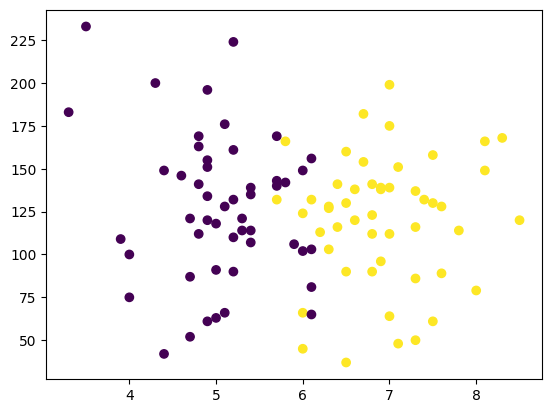

In [16]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [18]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [20]:
x
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [22]:
from sklearn.model_selection import train_test_split

x_train,x_test, y_train,y_test = train_test_split(x, y, test_size=0.1)

In [23]:
x_train

,cgpa,iq
99,6.2,113.0
97,6.7,182.0
45,6.0,66.0
17,3.3,183.0
64,7.0,64.0
...,...,...
38,6.5,160.0
44,7.5,61.0
94,4.7,52.0
70,6.3,127.0


In [24]:
y_train

,placement
99,1
97,1
45,1
17,0
64,1
...,...
38,1
44,1
94,0
70,1


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [26]:
x_train = scaler.fit_transform(x_train)

In [27]:
x_train

array([[ 0.21820828, -0.25371853],
       [ 0.65853889,  1.45331512],
       [ 0.04207604, -1.41648057],
       [-2.33570924,  1.47805473],
       [ 0.92273725, -1.46595981],
       [-0.22212233,  0.41425116],
       [-1.10278354, -0.05580158],
       [ 2.06759683,  1.10696046],
       [-1.36698191,  0.63690772],
       [ 0.13014216,  0.81008505],
       [ 0.57047276,  0.36477192],
       [ 0.92273725,  0.38951154],
       [ 0.74660501, -0.27845815],
       [ 0.39434052, -0.17949967],
       [-0.75051906, -1.41648057],
       [ 0.92273725, -0.27845815],
       [ 0.13014216,  0.21633422],
       [-0.57438681, -0.05580158],
       [-0.48632069,  0.38951154],
       [ 1.89146459,  0.63690772],
       [-1.19084966,  0.56268887],
       [ 0.3062744 ,  0.11737574],
       [ 1.18693561, -0.92168821],
       [ 1.89146459,  1.05748123],
       [-0.9266513 ,  0.68638696],
       [-0.9266513 , -1.54017866],
       [-0.57438681, -0.22897891],
       [ 0.48240664, -2.1339295 ],
       [ 0.92273725,

In [28]:
x_test = scaler.fit_transform(x_test)

In [29]:
x_test

array([[ 1.96493592, -0.19763779],
       [ 0.87330486,  0.31926104],
       [-1.40092654,  1.29224706],
       [ 1.14621262, -1.14021799],
       [-0.21832621, -1.86995751],
       [-0.855111  , -0.38007266],
       [-0.49123398,  1.20102962],
       [ 0.05458155,  0.44088429],
       [-1.03704952,  1.04900055],
       [-0.0363877 , -0.71453661]])

In [30]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [36]:
clf.fit(x_train, y_train)

LogisticRegression()

In [37]:
y_pred = clf.predict(x_test)

In [34]:
y_test

,placement
69,1
61,1
75,0
42,1
56,0
41,0
85,1
54,1
47,0
98,1


In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7

In [41]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

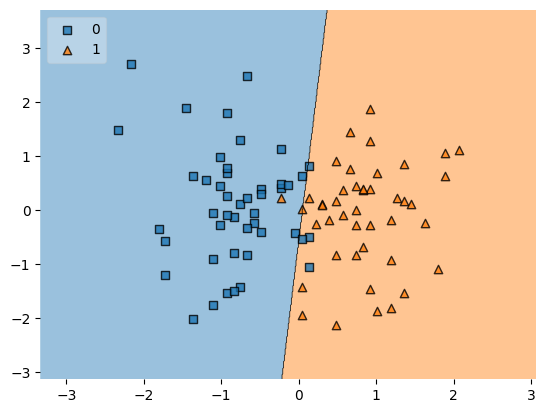

In [43]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [44]:
import pickle

In [45]:
pickle.dump(clf, open('model.pkl', 'wb'))